# NIRISS AMI Extraction

In this tutorial, we will read in simulated NIRISS AMI data using AMICAL, for a target-calibrator pair, and then visualize the data and extract calibrated observables.

In [1]:
from pathlib import Path

from astropy.io import fits

import amical

## Simulated NIRISS data

This example comes with two NIRISS simulated dataset representing
a relatively faint binary star (dm = 6) @ 4.3 μm :

- λ/D: sep = 147.7, theta = 46.6
- λ/D: sep = 302.0, theta = 260.9

We will use the first example for this tutorial.
Feel free to change the values to explore the other dataset.

In [2]:
sep = 147.7  # binary separation [mas]
theta = 46.6  # position angle (pa) [deg]
dm = 6.0  # contrast ratio [mag]

In our simulated data, `_t` is for target (astronomical scene) and `_c` for calibrator (point source)/

We point the path to target and calibrator files, then open these fits files as cubes.

In [3]:
datadir = Path("../NRM_DATA/")
file_pattern = f"binary_s={sep:2.1f}mas_mag=6.0_dm={dm:2.1f}_posang={theta:2.1f}__F430M_81_flat_x11__00.fits"
file_t = datadir / f"t_{file_pattern}"
file_c = datadir / f"c_{file_pattern}"

In [4]:
hdul = fits.open(file_t)
cube_t = hdul[0].data
hdul.info()
hdul.close()

Filename: ../NRM_DATA/t_binary_s=147.7mas_mag=6.0_dm=6.0_posang=46.6__F430M_81_flat_x11__00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      92   (81, 81, 316)   float64   


In [5]:
hdul = fits.open(file_c)
cube_c = hdul[0].data
hdul.info()
hdul.close()

Filename: ../NRM_DATA/c_binary_s=147.7mas_mag=6.0_dm=6.0_posang=46.6__F430M_81_flat_x11__00.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      92   (81, 81, 316)   float64   


Additional cleaning steps would be required for real NIRISS data
or MIRAGE simulations (bad pixel, centering, and background).
See the [getting started](../../getting-started/) and [SPHERE](../sphere-extraction/)
tutorials for more on this.
However, with the current simulations we can jump straight to the
observable extraction!

## Extracting Observables

We extract raw complex observables for both the target and the calibrator.

/home/vandal/repos/astro/AMICAL/src/amical/tools.py:448: RuntimeWarning: No SCI header for NIRISS. No PA correction will be applied.
  l_pa = fct_pa(**kwargs_pa)


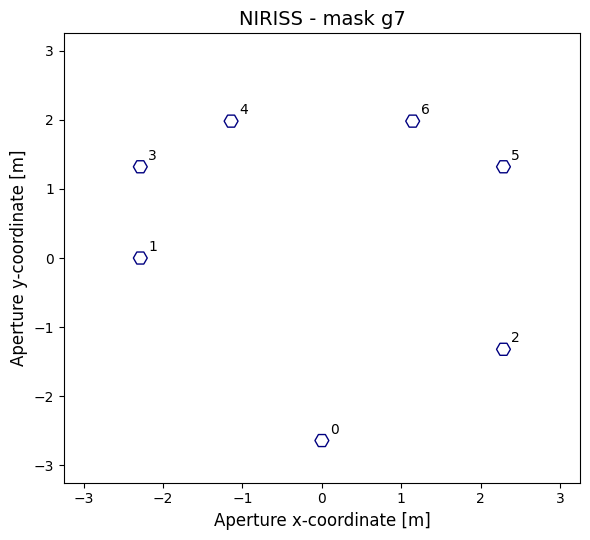

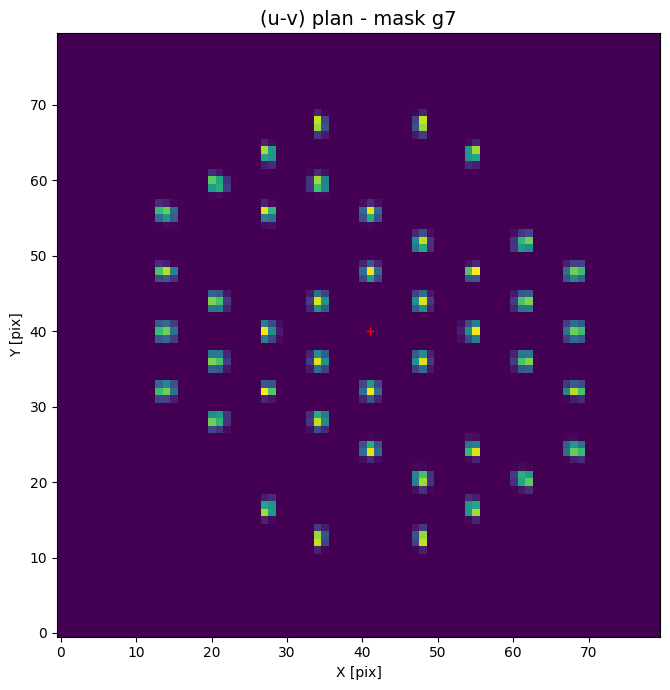

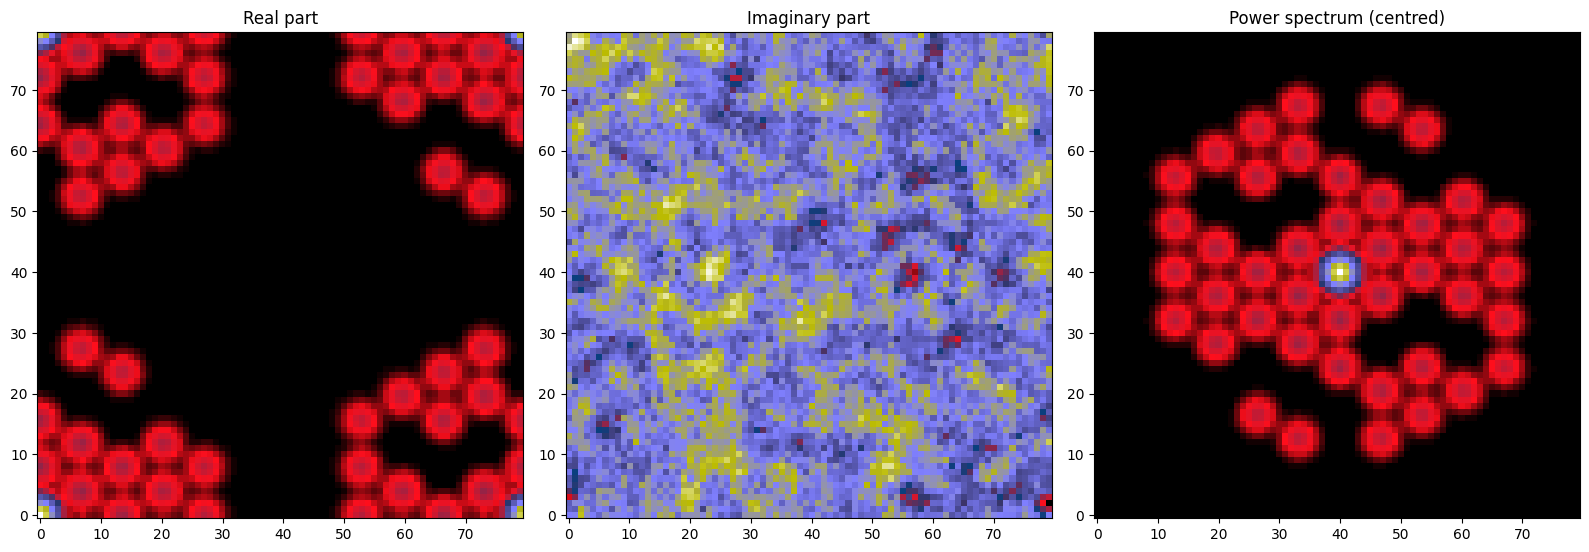

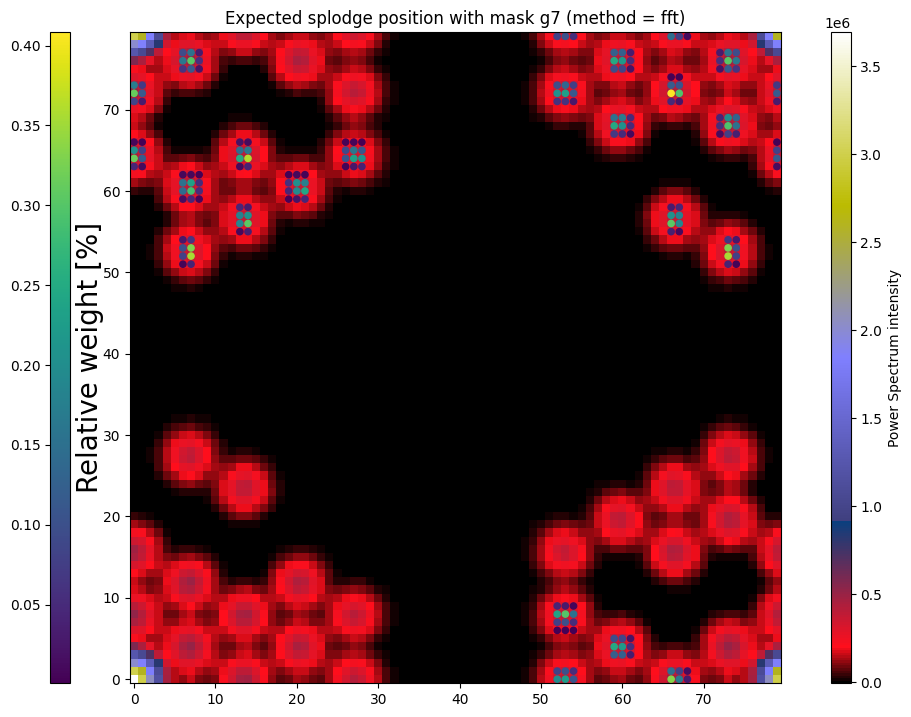

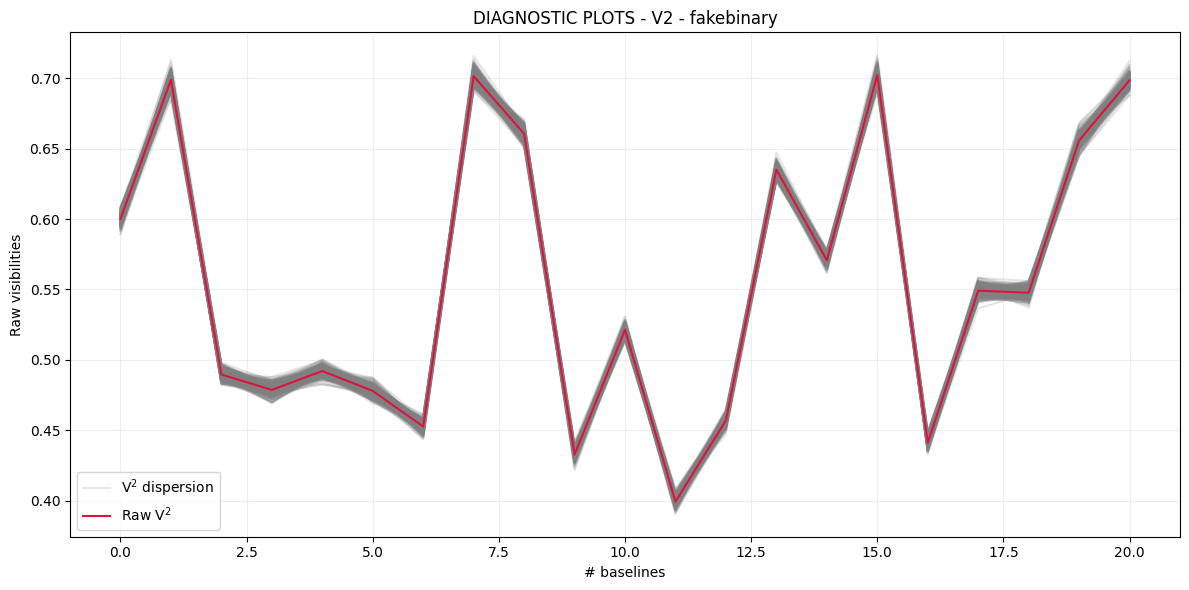

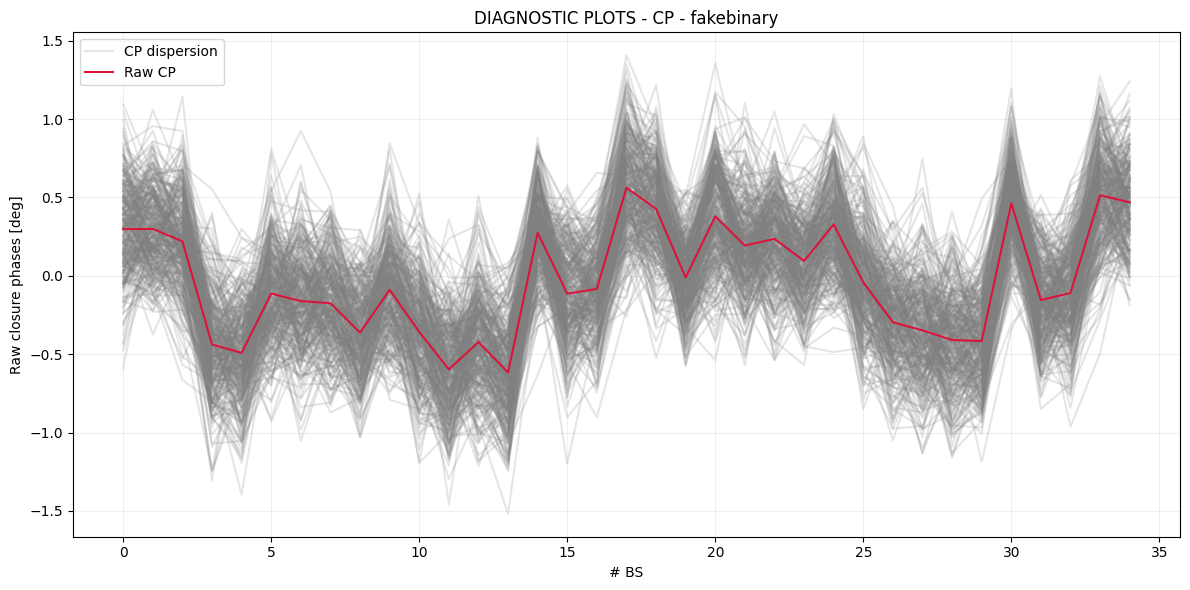

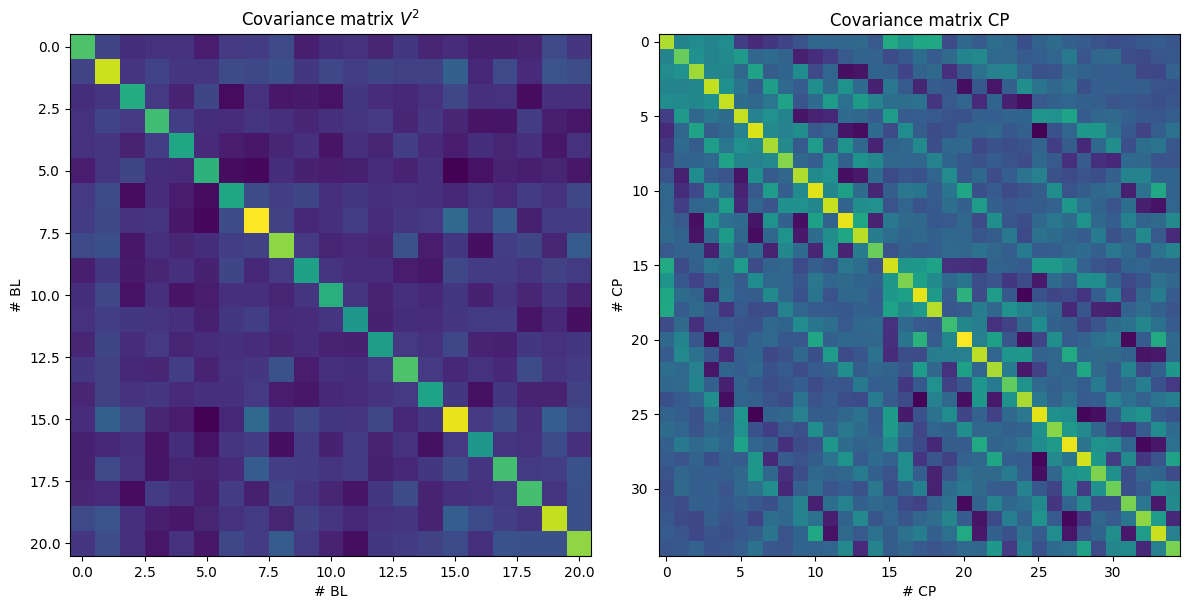

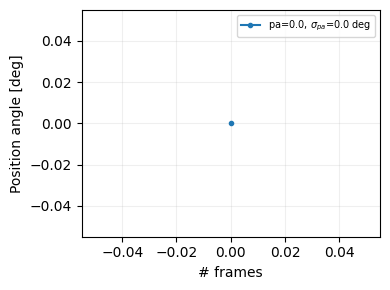

In [6]:
params_ami = {
    "peakmethod": "fft",
    "bs_multi_tri": False,
    "maskname": "g7",
    "fw_splodge": 0.7,
}

bs_t = amical.extract_bs(
    cube_t, file_t, targetname="fakebinary", **params_ami, display=True
)
bs_c = amical.extract_bs(
    cube_c, file_c, targetname="fakepsf", **params_ami, display=False
)

## Calibration

Now we calibrate the raw data to get calibrated visibility amplitudes (V2)
and closure phases (CP).

In [7]:
cal = amical.calibrate(bs_t, bs_c)

Finally, we can display the calibrated observables.
We will also save them to an OIFITS file so they can be re-used in the
[companion search tutorial](../companion-search/).


 -- SHOW -- Inputs are classes from amical.calibrate:
-> (Check true_flag_v2, true_flag_t3 and snr parameters)

### Create Saveoifits directory to save all requested Oifits ###


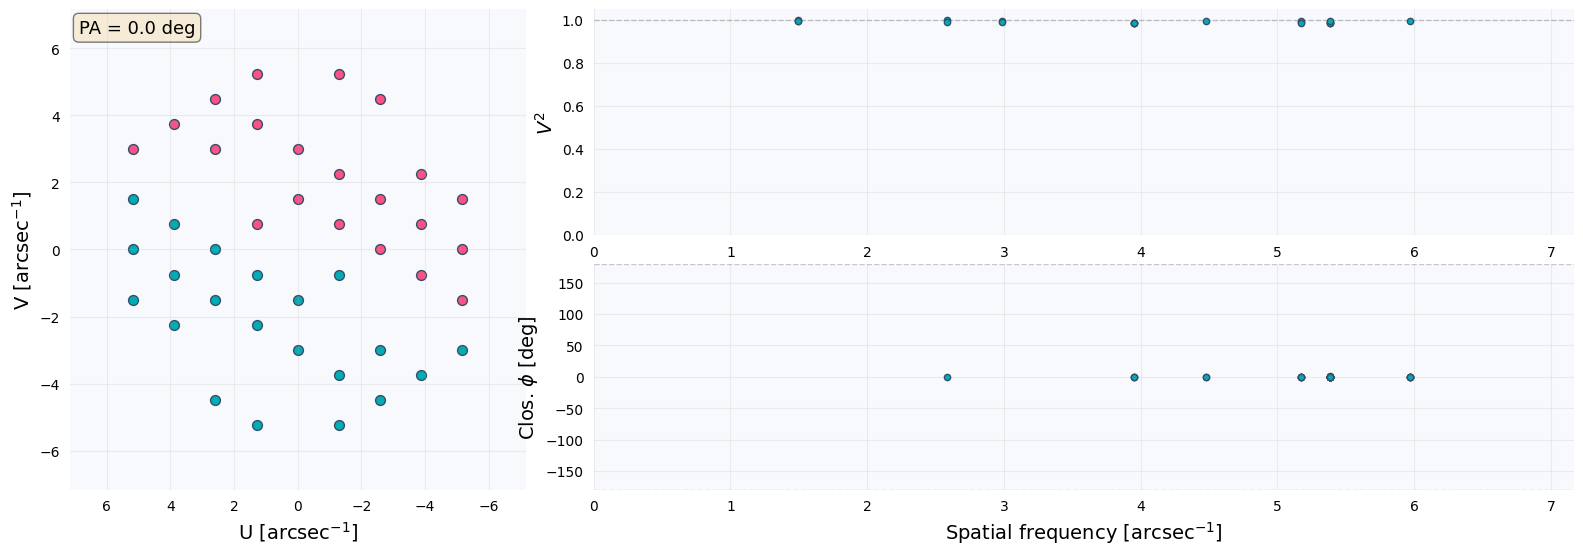

In [8]:
amical.show(cal)
_ = amical.save(cal, oifits_file="example_fakebinary_NIRISS.oifits", fake_obj=True)